<a href="https://colab.research.google.com/github/MeherNaaz19/NLP/blob/main/2303A51902_B09_A_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('/content/bbc_news.csv')

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from string import punctuation
import nltk
import string
from nltk.stem import WordNetLemmatizer # Import WordNetLemmatizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet') # Download the wordnet corpus
nltk.download('punkt_tab') # Download punkt_tab
lemmatizer = WordNetLemmatizer() # Initialize the lemmatizer
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    text=text.lower()
    text=text.translate(str.maketrans('', '', string.punctuation)) # Remove punct
    text=re.sub(r'[^a-zA-Z0-9\s]', '', text)
    tokens=word_tokenize(text)#tokenization
    stop_words=set(stopwords.words('english'))#stop words
    tokens=[word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens] # Lemmatization
    return " ".join(tokens)
df["cleaned_text"]=df["description"].astype(str).apply(preprocess_text)
print(df)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                                   title  \
0      Ukraine: Angry Zelensky vows to punish Russian...   
1      War in Ukraine: Taking cover in a town under a...   
2             Ukraine war 'catastrophic for global food'   
3      Manchester Arena bombing: Saffie Roussos's par...   
4      Ukraine conflict: Oil price soars to highest l...   
...                                                  ...   
42110           Highlights: Wales make history in Dublin   
42111  Gang jailed over £200m of cocaine in banana boxes   
42112   Scottish Budget presents huge challenges for SNP   
42113  Celebrations as Wales make history qualifying ...   
42114  School tells Muslim girls it’s ‘not safe’ for ...   

                             pubDate  \
0      Mon, 07 Mar 2022 08:01:56 GMT   
1      Sun, 06 Mar 2022 22:49:58 GMT   
2      Mon, 07 Mar 2022 00:14:42 GMT   
3      Mon, 07 Mar 2022 00:05:40 GMT   
4      Mon, 07 Mar 2022 08:15:53 GMT   
...                              ...   

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# For LDA
count_vectorizer = CountVectorizer(max_df=0.95, min_df=2)
count_data = count_vectorizer.fit_transform(df["cleaned_text"])
# For NMF
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2)
tfidf_data = tfidf_vectorizer.fit_transform(df["cleaned_text"])

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

num_topics = 4
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_model.fit(count_data)


LatentDirichletAllocation(n_components=4, random_state=42)

In [ ]:
from sklearn.decomposition import NMF

nmf_model = NMF(n_components=num_topics, random_state=42)
nmf_model.fit(tfidf_data)


NMF(n_components=4, random_state=42)

LDA Topics:

Topic 1:
say, police, year, two, people, show, died, death, woman, man


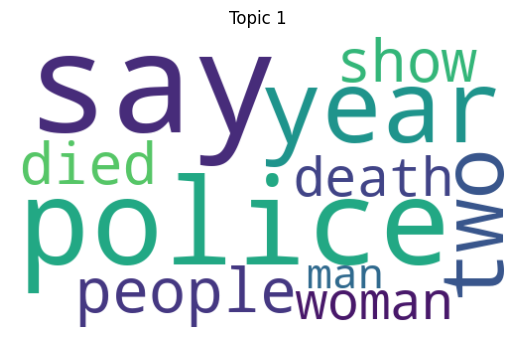


Topic 2:
say, bbc, uk, government, people, new, minister, party, leader, election


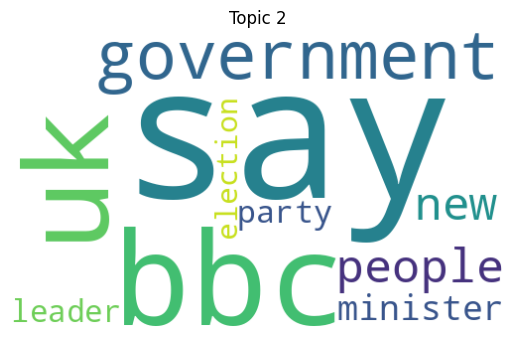


Topic 3:
say, ukraine, russia, russian, year, uk, city, people, cost, price


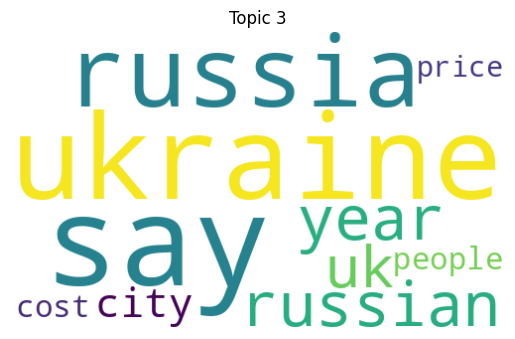


Topic 4:
world, england, cup, win, league, first, final, manchester, day, champion


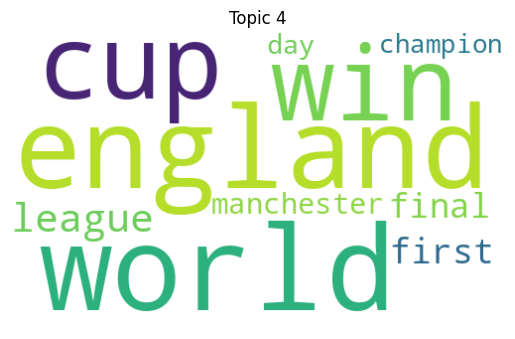

NMF Topics:

Topic 1:
uk, people, year, bbc, new, minister, election, government, first, two


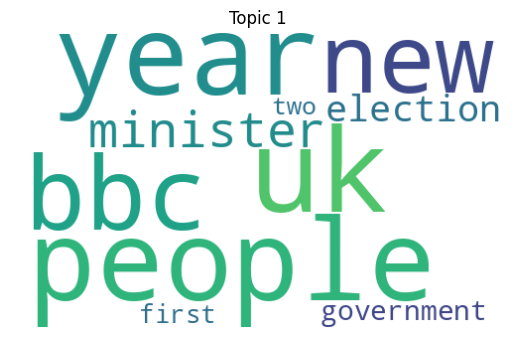


Topic 2:
day, seven, past, closely, attention, paying, going, whats, selection, image


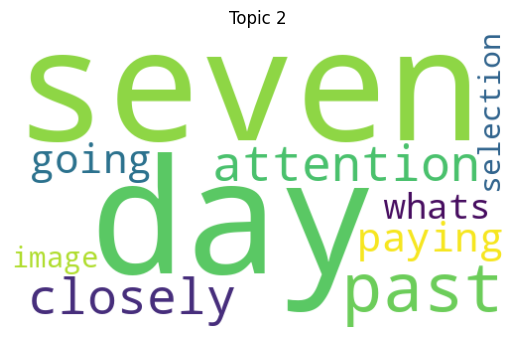


Topic 3:
world, cup, england, win, league, final, womens, manchester, first, watch


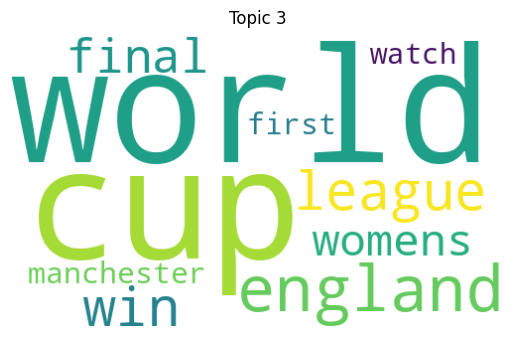


Topic 4:
say, police, attack, man, woman, official, ukraine, family, officer, president


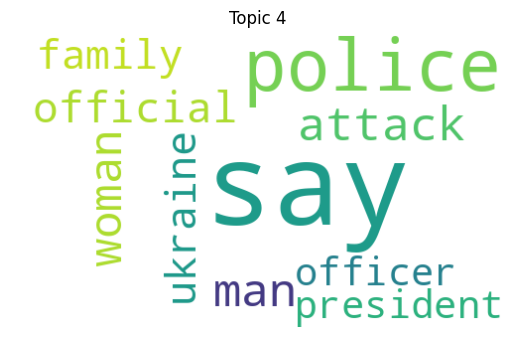

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def plot_top_words(model, feature_names, n_top_words=10, title="Topics"):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic {topic_idx+1}:")
        top_features_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_idx]
        print(", ".join(top_features))

        # Wordcloud
        word_freq = {feature_names[i]: topic[i] for i in top_features_idx}
        wc = WordCloud(width=500, height=300, background_color='white').generate_from_frequencies(word_freq)
        plt.figure()
        plt.imshow(wc, interpolation="bilinear")
        plt.axis('off')
        plt.title(f"Topic {topic_idx+1}")
        plt.show()

print("LDA Topics:")
plot_top_words(lda_model, count_vectorizer.get_feature_names_out())

print("NMF Topics:")
plot_top_words(nmf_model, tfidf_vectorizer.get_feature_names_out())
